# Trabajo Tema 4

Modelos de clasificación y clustering

Para la nota se tendrá en cuenta principalmente (80% de nota):
+ Comentarios de línea: La tarea básicamente es copiar código que ya existe en un libro o que os de una IA. Pero debéis entenderlo, explicando qué hace mediante comentarios.
+ Análisis de los resultados obtenidos en celdas Markdown.


# Parte 1: Clustering (6 puntos)

Esta parte trata de replicar y analizar los ejemplos resueltos del libro en PDF que está presente en el repositorio de GitHub

https://github.com/rpastorvargas/IntroductionToMachineLearningForSecurityPros

El código se proporciona (actualizado a Python 3, ya que el libro es antiguo) en el mismo repositorio, dentro del __directorio clustering_example__. 

El código está en archivos Python independientes, pero debéis entregar un Notebook donde se incluyan código, comentarios de línea y análisis/comparación de resultados en formato Markdown.

Como comentarios de análisis se deben indicar los resultados obtenidos en cada caso (K-Means y DBSCAN ) y compararlos con los correspondientes del libro. Es importante tener en cuenta que los resultados mostrados en el libro se corresponden con un subconjunto de los datos incluidos en el repositorio GitHub, por lo cual los resultados serán diferentes. 

El análisis y comparación se debe realizar de forma cualitativa para determinar si son coherentes y compatibles, fijandose más en los porcentajes en lugar de las cantidades absolutas.

También es importante repetir, al menos un par de veces, las ejecuciones de entrenamiento o ajuste (no las de vectorización o preparación de datos) para ver cómo afecta la aleatoriedad de los algoritmos y observar si hay algún cambio en los resultados.

## 1.1. CLUSTERING CON K-MEANS

El ejemplo comienza en página 23, "Cluster analysis with K-Means".

Debéis:
1. Copiar el código de cada archivo en su celda correspondiente. 
2. Analizar el código, entenderlo y __poner comentarios de línea__ explicando qué hace cada parte.
3. Ejecutar cada parte del código
4. Comentar el resultado obtenido y comparar los resultados con los del libro en celda Markdown.

Los archivos Python facilitados están construidos para ser ejecutados desde el terminal, pasando datos por parámetros. Debéis modificar y limpiar (lo que sobre) para que se ejecuten directamente desde el Notebook sin necesidad de recibir parámetros.

### Step 1: Vectorización y normalización

In [32]:
import numpy as np
import os
import re
import h5py
import socket
import struct
import pandas as pd
from sklearn.preprocessing import normalize

# --- CONFIGURACIÓN Y FUNCIONES ---
LOG_REGEX = re.compile(r'(\S+)\s\S+\s\S+\s\[[^\]]+\]\s"(\S*)\s[^"]*"\s(\d+)')

def ip2int(addr):
    try:
        return struct.unpack("!I", socket.inet_aton(addr))[0]
    except:
        return 0

def process_logs(data_path="data/www.secrepo.com/self.logs/"):
    # Inicialización con IPs requeridas
    prevectors = {
        ip2int("192.187.126.162"): {"requests": {}, "responses": {}},
        ip2int("49.50.76.8"): {"requests": {}, "responses": {}},
        ip2int("70.32.104.50"): {"requests": {}, "responses": {}},
    }
    
    # Definición de esquema de columnas
    request_types = ["GET", "POST", "HEAD", "OPTIONS", "PUT", "TRACE"]
    response_codes = [200, 404, 403, 304, 301, 206, 418, 416, 400, 405, 503, 500]
    feature_names = request_types + [str(code) for code in response_codes]

    # 1. Extracción de datos de archivos
    if os.path.exists(data_path):
        for path in os.listdir(data_path):
            full_path = os.path.join(data_path, path)
            if not os.path.isfile(full_path): continue
            with open(full_path, "r") as f:
                for line in f:
                    try:
                        match = LOG_REGEX.findall(line)
                        if not match: continue
                        ip_str, req_type, resp_code = match[0]
                        ip = ip2int(ip_str)
                        resp_code = int(resp_code)
                        
                        if ip not in prevectors:
                            if len(prevectors) >= 10000: continue
                            prevectors[ip] = {"requests": {}, "responses": {}}
                        
                        prevectors[ip]["requests"][req_type] = prevectors[ip]["requests"].get(req_type, 0) + 1
                        prevectors[ip]["responses"][resp_code] = prevectors[ip]["responses"].get(resp_code, 0) + 1
                    except:
                        continue
    else:
        print(f"⚠️ Alerta: No se encontró la ruta {data_path}. Generando datos vacíos/ejemplo.")

    # 2. Conversión a matriz numérica
    vectors = np.zeros((len(prevectors), len(feature_names)), dtype=np.float32)
    ips = []
    
    for idx, (ip, data) in enumerate(prevectors.items()):
        ips.append(ip)
        for i, r_type in enumerate(request_types):
            vectors[idx, i] = data["requests"].get(r_type, 0)
        for i, r_code in enumerate(response_codes):
            vectors[idx, len(request_types) + i] = data["responses"].get(r_code, 0)
            
    return ips, vectors, feature_names

# --- EJECUCIÓN PRINCIPAL ---
ips, vectors, columns = process_logs()

# Normalización L2
vectors_norm = normalize(vectors) if vectors.size > 0 else vectors

# Guardado en HDF5
with h5py.File("secrepo.h5", "w") as f:
    f.create_dataset("vectors", data=vectors_norm)
    f.create_dataset("cluster", data=np.zeros((vectors_norm.shape[0],), dtype=np.int32))
    f.create_dataset("notes", data=np.array(ips))

print(f"✅ Archivo 'secrepo.h5' creado con {len(ips)} registros.")

# Visualización inmediata en el Notebook
df_result = pd.DataFrame(vectors_norm, columns=columns)
df_result.insert(0, "IP_Address_Int", ips)
df_result.head(10) # Muestra las primeras 10 filas

✅ Archivo 'secrepo.h5' creado con 10000 registros.


,IP_Address_Int,GET,POST,HEAD,OPTIONS,PUT,TRACE,200,404,403,304,301,206,418,416,400,405,503,500
0,3233513122,0.147442,0.000000,0.786357,0.0,0.0,0.0,0.098295,0.393179,0.0,0.0,0.442326,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,825379848,0.408248,0.408248,0.000000,0.0,0.0,0.0,0.000000,0.816497,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,1176528946,0.408248,0.408248,0.000000,0.0,0.0,0.0,0.000000,0.816497,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,2913827627,0.707107,0.000000,0.000000,0.0,0.0,0.0,0.707107,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,778912667,0.820648,0.000000,0.000000,0.0,0.0,0.0,0.397501,0.012823,0.0,0.0,0.000000,0.410324,0.0,0.0,0.0,0.0,0.0,0.0
5,3236160002,0.707107,0.000000,0.000000,0.0,0.0,0.0,0.707107,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
6,1753391398,0.847340,0.000000,0.000000,0.0,0.0,0.0,0.282447,0.136354,0.0,0.0,0.428540,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
7,1753391397,0.851767,0.000000,0.000000,0.0,0.0,0.0,0.247787,0.178097,0.0,0.0,0.425883,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
8,402556964,0.707107,0.000000,0.000000,0.0,0.0,0.0,0.707107,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
9,1753391191,0.844010,0.000000,0.000000,0.0,0.0,0.0,0.312284,0.109721,0.0,0.0,0.422005,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


Las ips que hemos introducido manualmente se encuentran en espacios distintos en el espacio vectorial, esto ayudara al algoritmo KMeans a agruparlas correctamente

### Step 2: Visualización de PCA

Carga exitosa. Forma de los vectores: (10000, 18)


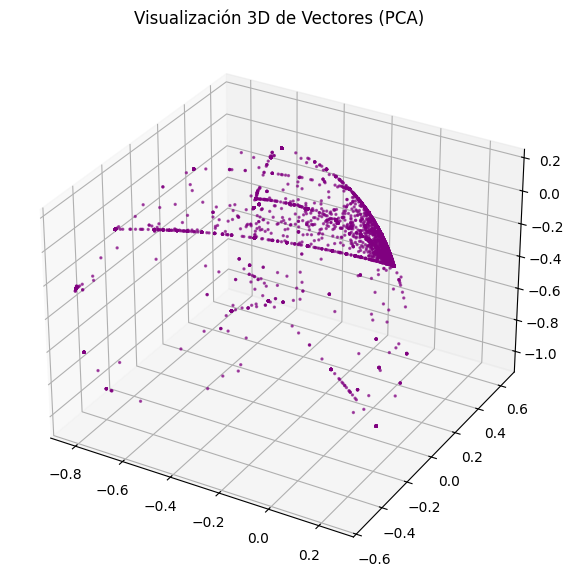

In [33]:
# código(repito imports para poder ejecutarlos individualmente)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import h5py

# 1. Definir la ruta del archivo
path = "secrepo.h5" 

# 2. Cargar los vectores desde el archivo HDF5
try:
    with h5py.File(path, "r") as f:
        vectors = f["vectors"][:]
    print(f"Carga exitosa. Forma de los vectores: {vectors.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'secrepo.h5' en la carpeta actual.")

# 3. Aplicar PCA para reducir a 3 dimensiones (necesario para visualizar)
pca = PCA(n_components=3)
projected_vectors = pca.fit_transform(vectors)

# 4. Crear la visualización 3D usando Matplotlib
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    projected_vectors[:, 0],
    projected_vectors[:, 1],
    projected_vectors[:, 2],
    s=2,         # Tamaño de los puntos
    alpha=0.6,   # Transparencia
    c='purple'   # Color
)

ax.set_title("Visualización 3D de Vectores (PCA)")
plt.show()

#### Comentarios

### Step 3: First Pass Clustering with K-Means

In [36]:
import h5py # Librería para leer y escribir archivos de datos HDF5 [1].
from sklearn.cluster import KMeans # Algoritmo K-Means para agrupamiento no supervisado [1].
import numpy as np # Librería para operaciones numéricas y manejo de arrays [1].
from collections import Counter # Para contar cuántas muestras han caído en cada clúster [1].

# --- Configuración para el Notebook ---
input_path = "secrepo.h5" # Archivo con los vectores generados originalmente [1, 2].
output_path = "secrepo_clustered.h5" # Archivo donde guardaremos los resultados [1].
n_clusters = 2 # Definimos 2 clústeres para la "primera pasada" (puedes ajustarlo después) [1].

try:
    # 1. Cargar los datos vectorizados
    with h5py.File(input_path, "r") as f:
        vectors = f["vectors"][:] # Cargamos la matriz de características [1].
        ips = f["notes"][:] # Cargamos las IPs asociadas a cada vector [1].

    # 2. Configurar y ejecutar el modelo K-Means
    # n_clusters define cuántos grupos queremos que el algoritmo intente encontrar.
    kmeans = KMeans(n_clusters=n_clusters)
    
    # fit_predict entrena el modelo y asigna una etiqueta de clúster a cada vector [1].
    clusters = kmeans.fit_predict(vectors)

    # 3. Mostrar un resumen de los resultados en consola
    counter = Counter(clusters.tolist()) # Contamos cuántas IPs hay en el Grupo 0, Grupo 1, etc. [1].
    print(f"--- Resumen del Clustering (K={n_clusters}) ---")
    for key in sorted(counter.keys()):
        # Imprime el número de muestras por cada etiqueta encontrada [1].
        print(f"Etiqueta {key}: tiene {counter[key]} muestras")

    # 4. Guardar los resultados para los siguientes pasos (Validación e Inspección)
    # --- Guardar en el archivo HDF5 ---

    with h5py.File("secrepo_clustered.h5", "w") as f:
        # 1. Guardar los vectores (Matriz completa)
        f.create_dataset("vectors", data=vectors)
        
        # 2. Guardar los clusters (Array de una dimensión)
        # clusters.shape ya es una tupla, por ejemplo (100,)
        f.create_dataset("cluster", data=clusters, dtype=np.int32)
        
        # 3. Guardar las IPs
        # Asegúrate de que 'ips' sea un array de numpy
        ips_array = np.array(ips)
        f.create_dataset("notes", data=ips_array)
    
    print(f"\n¡Éxito! Los resultados se han guardado en: {output_path}")

except FileNotFoundError:
    print(f"Error: No se encontró '{input_path}'. Asegúrate de haber ejecutado la vectorización primero.")


--- Resumen del Clustering (K=2) ---
Etiqueta 0: tiene 2296 muestras
Etiqueta 1: tiene 7704 muestras

¡Éxito! Los resultados se han guardado en: secrepo_clustered.h5


Cada IP recibe una etiqueta numérica (0 o 1 en este caso). Las IPs que se comportan de forma parecida (por ejemplo, todas las que hacen muchos escaneos que resultan en errores 404) deberían recibir la misma etiqueta

#### Step 4: Validating Our Cluster Statistically

In [37]:
import h5py
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances

# --- CONFIGURACIÓN ---
FILE_PATH = "secrepo.h5"  # Cambia esto por la ruta de tu archivo
N_CLUSTERS = 5               # Define el número de clusters deseado

# --- CARGA DE DATOS ---
with h5py.File(FILE_PATH, "r") as f:
    vectors = f["vectors"][:]
    # Si 'notes' contiene IPs en formato int, los convertimos a string (opcional)
    # ips = [socket.inet_ntoa(struct.pack("!I", ip)) for ip in f["notes"][:]]

print(f"Dataset cargado: {vectors.shape}")

# --- EJECUCIÓN DE K-MEANS ---
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init='auto', random_state=42)
clusters = kmeans.fit_predict(vectors)

# --- ESTADÍSTICAS GLOBALES ---
print("--- Estadísticas de los Vectores ---")
print(f"Min: {vectors.min():.4f} | Max: {vectors.max():.4f} | Mean: {vectors.mean():.4f}")
null_perc = 100.0 * (np.count_nonzero(vectors == 0) / vectors.size)
print(f"Porcentaje de valores nulos: {null_perc:.2f}%")

# --- ANÁLISIS DE CLUSTERS (SILHOUETTE) ---
# Nota: Silhouette puede ser lento con datasets muy grandes
score_avg = silhouette_score(vectors, clusters)
sample_scores = silhouette_samples(vectors, clusters)

print(f"\nSilhouette Score Global: {score_avg:.4f}")
print("-" * 50)

# --- MÉTRICAS POR CLUSTER ---
for i in range(N_CLUSTERS):
    cluster_data = vectors[clusters == i]
    cluster_scores = sample_scores[clusters == i]
    
    # Distancia media de los puntos al centroide de su propio cluster
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    dists_to_centroid = pairwise_distances(cluster_data, centroid)
    
    size_perc = (len(cluster_data) / len(vectors)) * 100
    
    print(f"Cluster {i}:")
    print(f"  Elementos: {len(cluster_data)} ({size_perc:.1f}%)")
    print(f"  Silhouette medio: {cluster_scores.mean():.4f}")
    print(f"  Distancia media al centroide: {dists_to_centroid.mean():.4f}")
    print("-" * 20)

Dataset cargado: (10000, 18)
--- Estadísticas de los Vectores ---
Min: 0.0000 | Max: 0.8839 | Mean: 0.0828
Porcentaje de valores nulos: 85.84%

Silhouette Score Global: 0.5897
--------------------------------------------------
Cluster 0:
  Elementos: 6169 (61.7%)
  Silhouette medio: 0.8345
  Distancia media al centroide: 0.0566
--------------------
Cluster 1:
  Elementos: 2537 (25.4%)
  Silhouette medio: 0.0133
  Distancia media al centroide: 0.3043
--------------------
Cluster 2:
  Elementos: 211 (2.1%)
  Silhouette medio: 0.1575
  Distancia media al centroide: 0.4785
--------------------
Cluster 3:
  Elementos: 586 (5.9%)
  Silhouette medio: 0.7217
  Distancia media al centroide: 0.1538
--------------------
Cluster 4:
  Elementos: 497 (5.0%)
  Silhouette medio: 0.5225
  Distancia media al centroide: 0.3229
--------------------


El score es alto. Los patrones de tráfico están claramente diferenciados. el Coeficiente de Silueta esta mas cerca del +1 que del 0, por lo que significa que esta en los clusteres estan bien definidos y separados, los clusters con mas cantidad de elementos(el 0 y el 1) tienen una cohesion muy pequeña, lo cual significa que eson compactos

### Step 5: Inspecting Our Clusters

In [38]:
# código
import h5py # Librería para leer el archivo de datos HDF5 generado en los pasos previos [1].
import socket # Permite realizar operaciones de red [1].
import struct # Ayuda a convertir datos binarios (como IPs en formato entero) a tipos de Python [1, 2].

def int2ip(addr):
    """
    Función auxiliar que convierte un número entero de 32 bits de vuelta 
    a una dirección IP legible (ej: 192.168.1.1) [1].
    """
    return socket.inet_ntoa(struct.pack("!I", addr))

# --- Configuración para ejecución en Notebook ---
# Definimos la ruta del archivo que ya contiene las etiquetas de los clústeres.
path = "secrepo_clustered.h5" 
cluster_a_inspeccionar = None # Cambia esto por un número (ej: 0, 1) si solo quieres ver un clúster específico.

try:
    # Abrimos el archivo en modo lectura [1].
    with h5py.File(path, "r") as f:
        # Extraemos los vectores, las notas (IPs en formato entero) y las etiquetas de clúster [1].
        vectors = f["vectors"][:]
        ips = f["notes"][:]
        clusters = f["cluster"][:]

    print(f"--- Inspeccionando Clústeres en {path} ---")

    if cluster_a_inspeccionar is None:
        # Si no se especifica un clúster, recorremos todos los identificadores únicos encontrados [1].
        for cluster_id in sorted(set(clusters.tolist())):
            print(f"\nResultados para el Clúster {cluster_id}:")
            # Filtramos las IPs que pertenecen al clúster actual y las convertimos a formato legible [1].
            for ip in ips[clusters == cluster_id]:
                print(f"Clúster {cluster_id} -> IP: {int2ip(ip)}")
    else:
        # Si se especificó uno, solo mostramos los miembros de ese clúster [1].
        print(f"\nMiembros del Clúster {cluster_a_inspeccionar}:")
        for ip in ips[clusters == cluster_a_inspeccionar]:
            print(f"IP: {int2ip(ip)}")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo {path}. Asegúrate de haber ejecutado el paso de clustering previamente.")

--- Inspeccionando Clústeres en secrepo_clustered.h5 ---

Resultados para el Clúster 0:
Clúster 0 -> IP: 192.187.126.162
Clúster 0 -> IP: 49.50.76.8
Clúster 0 -> IP: 70.32.104.50
Clúster 0 -> IP: 104.130.161.38
Clúster 0 -> IP: 104.130.161.37
Clúster 0 -> IP: 104.130.160.87
Clúster 0 -> IP: 104.130.20.53
Clúster 0 -> IP: 71.164.230.33
Clúster 0 -> IP: 50.97.94.48
Clúster 0 -> IP: 166.216.157.15
Clúster 0 -> IP: 54.80.124.105
Clúster 0 -> IP: 173.59.251.17
Clúster 0 -> IP: 73.26.128.175
Clúster 0 -> IP: 12.207.17.3
Clúster 0 -> IP: 213.130.111.50
Clúster 0 -> IP: 199.203.134.91
Clúster 0 -> IP: 194.203.214.50
Clúster 0 -> IP: 68.180.228.109
Clúster 0 -> IP: 109.67.37.159
Clúster 0 -> IP: 88.150.136.178
Clúster 0 -> IP: 183.207.228.14
Clúster 0 -> IP: 54.71.238.52
Clúster 0 -> IP: 172.56.3.149
Clúster 0 -> IP: 108.48.71.29
Clúster 0 -> IP: 78.245.91.140
Clúster 0 -> IP: 124.149.102.155
Clúster 0 -> IP: 128.111.185.97
Clúster 0 -> IP: 5.63.146.172
Clúster 0 -> IP: 112.111.185.157
Clúster 

Podemos comprobar que como comenta el libro las Ips que nosotros mismos pusimos aparecen en clusteres especificos, de esta manera si las reconocemos sabemos que ese cluster al que pertenecen la mayoria estaran realizando actividades similares

### Step 6: Modifying K to Optimize Cluster Results

Volver a aplicar el algoritmo cambiando el valor de k. Copia de nuevo el código. 

In [44]:
# códigoimport h5py # Librería para leer y escribir archivos de datos HDF5 [1].
from sklearn.cluster import KMeans # Algoritmo K-Means para agrupamiento no supervisado [1].
import numpy as np # Librería para operaciones numéricas y manejo de arrays [1].
from collections import Counter # Para contar cuántas muestras han caído en cada clúster [1].

# --- Configuración para el Notebook ---
input_path = "secrepo.h5" # Archivo con los vectores generados originalmente [1, 2].
output_path = "secrepo_clustered_2.h5" # Archivo donde guardaremos los resultados [1].
n_clusters = 5 # Definimos 2 clústeres para la "primera pasada" (puedes ajustarlo después) [1].

try:
    # 1. Cargar los datos vectorizados
    with h5py.File(input_path, "r") as f:
        vectors = f["vectors"][:] # Cargamos la matriz de características [1].
        ips = f["notes"][:] # Cargamos las IPs asociadas a cada vector [1].

    # 2. Configurar y ejecutar el modelo K-Means
    # n_clusters define cuántos grupos queremos que el algoritmo intente encontrar.
    kmeans = KMeans(n_clusters=n_clusters)
    
    # fit_predict entrena el modelo y asigna una etiqueta de clúster a cada vector [1].
    clusters = kmeans.fit_predict(vectors)

    # 3. Mostrar un resumen de los resultados en consola
    counter = Counter(clusters.tolist()) # Contamos cuántas IPs hay en el Grupo 0, Grupo 1, etc. [1].
    print(f"--- Resumen del Clustering (K={n_clusters}) ---")
    for key in sorted(counter.keys()):
        # Imprime el número de muestras por cada etiqueta encontrada [1].
        print(f"Etiqueta {key}: tiene {counter[key]} muestras")

    # 4. Guardar los resultados para los siguientes pasos (Validación e Inspección)
    # --- Guardar en el archivo HDF5 ---

    with h5py.File(output_path, "w") as f:
        # 1. Guardar los vectores (Matriz completa)
        f.create_dataset("vectors", data=vectors)
        
        # 2. Guardar los clusters (Array de una dimensión)
        # clusters.shape ya es una tupla, por ejemplo (100,)
        f.create_dataset("cluster", data=clusters, dtype=np.int32)
        
        # 3. Guardar las IPs
        # Asegúrate de que 'ips' sea un array de numpy
        ips_array = np.array(ips)
        f.create_dataset("notes", data=ips_array)
    
    print(f"\n¡Éxito! Los resultados se han guardado en: {output_path}")

except FileNotFoundError:
    print(f"Error: No se encontró '{input_path}'. Asegúrate de haber ejecutado la vectorización primero.")

# 

--- Resumen del Clustering (K=5) ---
Etiqueta 0: tiene 5977 muestras
Etiqueta 1: tiene 726 muestras
Etiqueta 2: tiene 547 muestras
Etiqueta 3: tiene 116 muestras
Etiqueta 4: tiene 2634 muestras

¡Éxito! Los resultados se han guardado en: secrepo_clustered_2.h5


#### Comentarios

### Step 7: Repeating Our Inspection and Validation Procedures

In [45]:
# código
import h5py
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances

# --- CONFIGURACIÓN ---
FILE_PATH = "secrepo_clustered_2.h5"  # Cambia esto por la ruta de tu archivo
N_CLUSTERS = 5               # Define el número de clusters deseado

# --- CARGA DE DATOS ---
with h5py.File(FILE_PATH, "r") as f:
    vectors = f["vectors"][:]
    # Si 'notes' contiene IPs en formato int, los convertimos a string (opcional)
    # ips = [socket.inet_ntoa(struct.pack("!I", ip)) for ip in f["notes"][:]]

print(f"Dataset cargado: {vectors.shape}")

# --- EJECUCIÓN DE K-MEANS ---
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init='auto', random_state=42)
clusters = kmeans.fit_predict(vectors)

# --- ESTADÍSTICAS GLOBALES ---
print("--- Estadísticas de los Vectores ---")
print(f"Min: {vectors.min():.4f} | Max: {vectors.max():.4f} | Mean: {vectors.mean():.4f}")
null_perc = 100.0 * (np.count_nonzero(vectors == 0) / vectors.size)
print(f"Porcentaje de valores nulos: {null_perc:.2f}%")

# --- ANÁLISIS DE CLUSTERS (SILHOUETTE) ---
# Nota: Silhouette puede ser lento con datasets muy grandes
score_avg = silhouette_score(vectors, clusters)
sample_scores = silhouette_samples(vectors, clusters)

print(f"\nSilhouette Score Global: {score_avg:.4f}")
print("-" * 50)

# --- MÉTRICAS POR CLUSTER ---
for i in range(N_CLUSTERS):
    cluster_data = vectors[clusters == i]
    cluster_scores = sample_scores[clusters == i]
    
    # Distancia media de los puntos al centroide de su propio cluster
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    dists_to_centroid = pairwise_distances(cluster_data, centroid)
    
    size_perc = (len(cluster_data) / len(vectors)) * 100
    
    print(f"Cluster {i}:")
    print(f"  Elementos: {len(cluster_data)} ({size_perc:.1f}%)")
    print(f"  Silhouette medio: {cluster_scores.mean():.4f}")
    print(f"  Distancia media al centroide: {dists_to_centroid.mean():.4f}")
    print("-" * 20)

Dataset cargado: (10000, 18)
--- Estadísticas de los Vectores ---
Min: 0.0000 | Max: 0.8839 | Mean: 0.0828
Porcentaje de valores nulos: 85.84%

Silhouette Score Global: 0.5897
--------------------------------------------------
Cluster 0:
  Elementos: 6169 (61.7%)
  Silhouette medio: 0.8345
  Distancia media al centroide: 0.0566
--------------------
Cluster 1:
  Elementos: 2537 (25.4%)
  Silhouette medio: 0.0133
  Distancia media al centroide: 0.3043
--------------------
Cluster 2:
  Elementos: 211 (2.1%)
  Silhouette medio: 0.1575
  Distancia media al centroide: 0.4785
--------------------
Cluster 3:
  Elementos: 586 (5.9%)
  Silhouette medio: 0.7217
  Distancia media al centroide: 0.1538
--------------------
Cluster 4:
  Elementos: 497 (5.0%)
  Silhouette medio: 0.5225
  Distancia media al centroide: 0.3229
--------------------


#### Comentarios


### SELECCIÓN OPTIMA DE K MEDIANTE EL MÉTODO DEL CODO

Aplica K-Means en un bucle, desde k=2 a k=25, calculando la Inercia (WCSS) y graficandola (eje x es el valor de K, eje Y es la inercia)

Iniciando el cálculo de inercias para K de 2 a 25...
Cálculo finalizado.


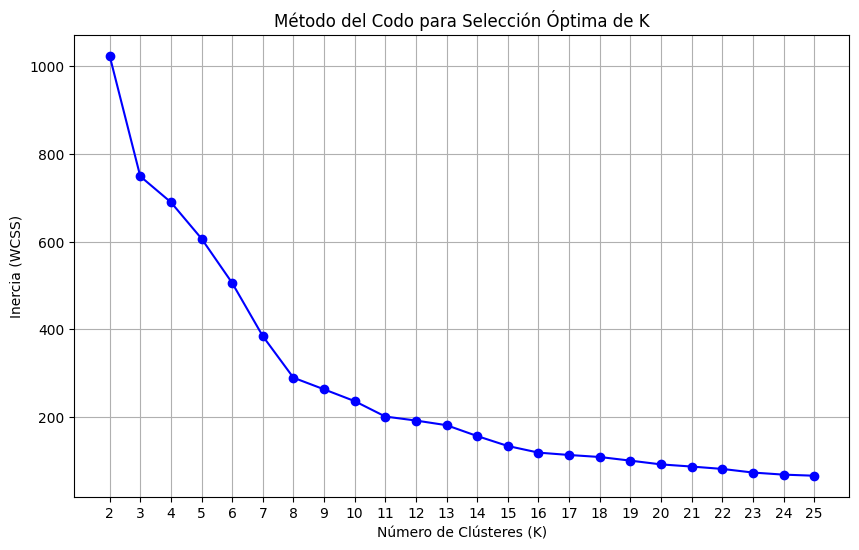

In [46]:
# código
import h5py
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Cargar los vectores desde el archivo generado en la vectorización
input_path = "secrepo.h5" 

try:
    with h5py.File(input_path, "r") as f:
        vectors = f["vectors"][:] # Cargamos la matriz de características [3]

    # 2. Aplicar K-Means en un bucle desde k=2 hasta k=25
    inercias = [] # Lista para almacenar la Inercia (WCSS) de cada modelo
    rango_k = range(2, 26)

    print("Iniciando el cálculo de inercias para K de 2 a 25...")
    for k in rango_k:
        # Inicializamos el modelo con el valor de k actual
        kmeans = KMeans(n_clusters=k, random_state=42)
        # Ajustamos el modelo a los datos
        kmeans.fit(vectors)
        # Extraemos la 'inercia_', que es el WCSS (Within-Cluster Sum of Squares)
        inercias.append(kmeans.inertia_)
        
    print("Cálculo finalizado.")

    # 3. Graficar los resultados
    plt.figure(figsize=(10, 6))
    plt.plot(rango_k, inercias, marker='o', linestyle='-', color='b')
    
    # Configuración de los ejes
    plt.title('Método del Codo para Selección Óptima de K')
    plt.xlabel('Número de Clústeres (K)')
    plt.ylabel('Inercia (WCSS)')
    plt.xticks(rango_k) # Asegura que todos los valores de K se muestren en el eje X
    plt.grid(True)
    
    plt.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{input_path}'. Asegúrate de haber completado la vectorización.")

Podemos comprobar que el "codo", el valor de K ultimo es sobre 11 donde la curva empieza a suavizarse, asi no estaremos sobreaustando ni dejando los clusteres demasiado genericos

---
## 1.2. CLUSTERING CON DBSCAN

El ejemplo comienza en página 31, "Cluster analysis with DBSCAN".

Como bien dice el libro, podemos saltarnos step 1 y 2 ya que los datos están vectorizados y normalizados en secrepo.h5. Además no es necesario volver a graficar.

Pasamos directamente a aplicar el algoritmo.

Debéis:
1. Copiar el código de cada archivo en su celda correspondiente.
2. Analizar el código, entenderlo y __poner comentarios de línea__ explicando qué hace cada parte.
3. Ejecutar cada parte del código
4. Comentar el resultado obtenido y comparar los resultados con los del libro en celda Markdown.

### Ejecución para hiperparámetros Eps=0.5 y MinPts=5

Meter ejecución del algoritmo y la inspección de resultados en 2 celdas consecutivas

In [47]:
# código del algoritmo
import h5py
import numpy as np
from sklearn.cluster import DBSCAN
from collections import Counter

# --- Configuración de parámetros ---
input_path = "secrepo.h5"  # Archivo de entrada con los vectores originales [2]
output_path = "secrepo_dbscan.h5" # Archivo para guardar los resultados de DBSCAN
epsilon = 0.5   # Distancia máxima entre dos muestras para que se consideren vecinas (Eps) [1]
min_points = 5  # Número mínimo de muestras en una vecindad para ser un punto núcleo (MinPts) [1]

try:
    # 1. Cargar datos vectorizados
    with h5py.File(input_path, "r") as f:
        vectors = f["vectors"][:]
        ips_raw = f["notes"][:]

    # 2. Configurar y ejecutar DBSCAN
    # eps es el radio de vecindad y min_samples es el MinPts [1]
    dbscan = DBSCAN(eps=epsilon, min_samples=min_points)
    clusters = dbscan.fit_predict(vectors)

    # 3. Mostrar resumen de etiquetas encontradas
    # La etiqueta -1 representa el 'ruido' o anomalías [1]
    counter = Counter(clusters.tolist())
    print(f"--- Resumen de DBSCAN (Eps={epsilon}, MinPts={min_points}) ---")
    for key in sorted(counter.keys()):
        label_name = "Ruido/Anomalía" if key == -1 else f"Clúster {key}"
        print(f"{label_name}: {counter[key]} muestras")

    # 4. Guardar resultados para inspección
    with h5py.File(output_path, "w") as f:
        f.create_dataset("vectors", data=vectors)
        f.create_dataset("cluster", data=clusters, dtype=np.int32)
        f.create_dataset("notes", data=ips_raw)
    
    print(f"\nResultados guardados exitosamente en: {output_path}")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{input_path}'.")

--- Resumen de DBSCAN (Eps=0.5, MinPts=5) ---
Ruido/Anomalía: 12 muestras
Clúster 0: 9967 muestras
Clúster 1: 9 muestras
Clúster 2: 6 muestras
Clúster 3: 6 muestras

Resultados guardados exitosamente en: secrepo_dbscan.h5


In [48]:
# código para ver/analizar los clusteres (step 4 y 5)
import h5py
import socket
import struct

def int2ip(addr):
    """Convierte el formato entero de la IP a una cadena legible (ej. 192.168.1.1) [2, 3]"""
    return socket.inet_ntoa(struct.pack("!I", addr))

# --- Configuración de inspección ---
path_resultados = "secrepo_dbscan.h5"

try:
    with h5py.File(path_resultados, "r") as f:
        ips = f["notes"][:]
        clusters = f["cluster"][:]

    print(f"--- Detalle de Miembros por Grupo ---")
    
    # Recorremos cada grupo identificado (incluyendo el -1 de ruido)
    for cluster_id in sorted(set(clusters.tolist())):
        print(f"\nID de Grupo: {cluster_id} " + ("(Ruido/Posibles Ataques)" if cluster_id == -1 else ""))
        
        # Filtramos y mostramos las IPs pertenecientes a este clúster [3]
        miembros_ip = ips[clusters == cluster_id]
        for ip_int in miembros_ip:
            print(f"  -> IP: {int2ip(ip_int)}")

except FileNotFoundError:
    print("Error: Ejecuta primero la celda de DBSCAN para generar los resultados.")


--- Detalle de Miembros por Grupo ---

ID de Grupo: -1 (Ruido/Posibles Ataques)
  -> IP: 54.80.124.105
  -> IP: 62.210.141.227
  -> IP: 117.15.162.240
  -> IP: 98.126.142.26
  -> IP: 117.169.1.209
  -> IP: 124.122.126.170
  -> IP: 117.25.79.152
  -> IP: 115.236.232.167
  -> IP: 122.237.72.179
  -> IP: 190.198.81.92
  -> IP: 202.70.44.14
  -> IP: 125.69.140.138

ID de Grupo: 0 
  -> IP: 192.187.126.162
  -> IP: 49.50.76.8
  -> IP: 70.32.104.50
  -> IP: 173.173.123.43
  -> IP: 46.109.67.155
  -> IP: 192.227.226.2
  -> IP: 104.130.161.38
  -> IP: 104.130.161.37
  -> IP: 23.254.136.36
  -> IP: 104.130.160.87
  -> IP: 104.130.20.53
  -> IP: 157.55.39.210
  -> IP: 157.55.39.128
  -> IP: 107.77.75.17
  -> IP: 166.216.165.56
  -> IP: 166.216.165.85
  -> IP: 71.164.230.33
  -> IP: 199.116.169.254
  -> IP: 134.134.137.73
  -> IP: 134.134.139.74
  -> IP: 174.103.122.67
  -> IP: 50.97.94.48
  -> IP: 166.216.157.15
  -> IP: 89.128.18.205
  -> IP: 66.87.119.77
  -> IP: 66.249.69.11
  -> IP: 66.249.6

En la etiqueta -1 encontramos ruidos, son Ips que no siguen el comportamiento lo suficiente similar al resto ni forman un grupo de 5 elementos

### Pruebas de otros hiperparámetros

Aquí no seguimos el libro. Debéis pobrar varios hiperparámetros y decidir cual se ajusta mejor. Es decir, solo quedáis en la celda de código una versión. 

Por ejemplo:
1. Eps=0.6
2. Eps=0.4

Y variar también MinPts.

In [49]:
# código
import h5py
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter

# --- Configuración de Hiperparámetros a probar ---
# Se reduce Eps a 0.4 para ser más estrictos con la cercanía de los puntos
# Se reduce MinPts a 3 para permitir la formación de clústeres más pequeños
input_path = "secrepo.h5"
epsilon = 0.4   # Radio de vecindad (Eps)
min_points = 3  # Mínimo de puntos para formar un núcleo (MinPts)

try:
    # 1. Carga de datos vectorizados
    with h5py.File(input_path, "r") as f:
        vectors = f["vectors"][:]
        ips_raw = f["notes"][:]

    # 2. Ejecución de DBSCAN con los nuevos parámetros
    dbscan = DBSCAN(eps=epsilon, min_samples=min_points)
    clusters = dbscan.fit_predict(vectors)

    # 3. Resumen estadístico de los resultados
    counts = Counter(clusters)
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)

    print(f"--- Resultados DBSCAN (Eps={epsilon}, MinPts={min_points}) ---")
    print(f"Clústeres encontrados: {n_clusters}")
    print(f"Puntos marcados como Ruido/Anomalía (-1): {n_noise} ({100*n_noise/len(clusters):.2f}%)")

    # 4. Validación mediante Silueta (Solo si hay más de un clúster)
    if n_clusters > 0:
        # Nota: La métrica de silueta no suele incluir el ruido (-1) para ser precisa
        mask = clusters != -1
        if np.sum(mask) > 1 and len(set(clusters[mask])) > 1:
            score = silhouette_score(vectors[mask], clusters[mask])
            print(f"Puntaje de Silueta (excluyendo ruido): {score:.4f}")
        else:
            print("No hay suficientes clústeres válidos para calcular la silueta.")
    
    # 5. Guardar resultados para inspección posterior [2]
    output_path = "secrepo_dbscan_tuned.h5"
    with h5py.File(output_path, "w") as f:
        f.create_dataset("vectors", data=vectors)
        f.create_dataset("cluster", data=clusters, dtype=np.int32)
        f.create_dataset("notes", data=ips_raw)
    print(f"\nResultados guardados en: {output_path}")

except FileNotFoundError:
    print(f"Error: No se encontró '{input_path}'. Asegúrate de haber realizado la vectorización.")

--- Resultados DBSCAN (Eps=0.4, MinPts=3) ---
Clústeres encontrados: 9
Puntos marcados como Ruido/Anomalía (-1): 11 (0.11%)
Puntaje de Silueta (excluyendo ruido): 0.5996

Resultados guardados en: secrepo_dbscan_tuned.h5


debes guiarte por estos tres criterios basados en las fuentes técnicas:
* Puntaje de Silueta alto: Un valor más cercano a 1 indica que los clústeres están bien definidos y separados entre sí

* Porcentaje de Ruido razonable: En seguridad, el ruido (etiqueta -1) suelen ser las anomalías. Si el 90% de tus datos es "ruido", el Eps es demasiado pequeño. Si el 0% es ruido, el Eps es demasiado grande y podrías estar ignorando ataques

* Fragmentación de Clústeres: Si al bajar MinPts aparecen muchísimos clústeres con solo 3 o 4 IPs, podrías estar sobreajustando el modelo a variaciones insignificantes del tráfico


Consejo: Si buscas detectar ataques específicos y poco comunes, un Eps bajo y un MinPts bajo (como el del código arriba) te ayudará a aislar comportamientos únicos como anomalías

---
# Parte 2: Regresión Logística (4 puntos)

En esta parte tendréis que investigar algo, no partimos de ningún libro.

El código entregado debe estar debidamente comentado, explicando qué es y qué hace cada instrucción, clase o método.

Puedes dividir en varias celdas según tu criterio.

Tareas a realizar:

1. Carga el dataset breast_cancer desde la librería sklearn.datasets.
2. Realiza una exploración inicial: ¿Cuántas muestras hay? ¿Cuántas características (features) definen cada caso? ¿están escaladas/normalizadas?
3. Divide los datos en dos conjuntos: 80% / 20%
4. Escala las características si no lo están. Debes aplicar también la transformación al conjunto de test.
5. Entrega el modelo LogisticRegression().
6. Genera y muestra la Matriz de Confusión.
7. Calcula métricas: Accuaracy_score, Precisión.
8. Analizar todos los resultados en los comentarios finales.

Número de muestras: 569
Número de características: 30
Media de la primera característica: 14.13
Máximo de la primera característica: 28.11


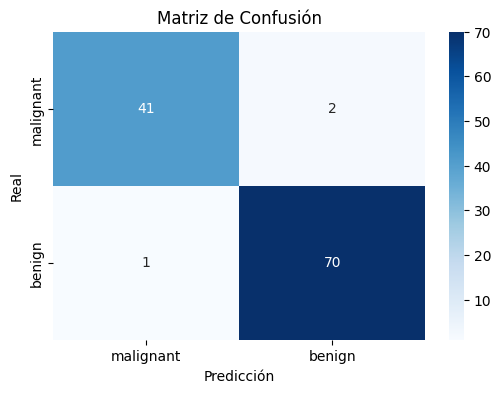

Accuracy (Exactitud): 0.9737
Precisión: 0.9722

Informe de Clasificación:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [52]:
# código
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report

# --- 1. Carga del dataset ---
data = load_breast_cancer()
X = data.data  # Características (features)
y = data.target # Etiquetas (0: Maligno, 1: Benigno)

# --- 2. Exploración inicial ---
n_muestras, n_features = X.shape
print(f"Número de muestras: {n_muestras}")
print(f"Número de características: {n_features}")

# ¿Están escaladas? Comprobamos medias y desviaciones
print(f"Media de la primera característica: {X[:,0].mean():.2f}")
print(f"Máximo de la primera característica: {X[:,0].max():.2f}")
# Respuesta: No están escaladas, ya que hay mucha diferencia de magnitudes entre columnas.

# --- 3. División del dataset (80% / 20%) ---
# random_state asegura que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 4. Escalado de características ---
# La regresión logística converge mejor si los datos están normalizados (StandardScaler: media 0, desv 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Ajusta y transforma entrenamiento
X_test = scaler.transform(X_test)       # Solo transforma test (usa los parámetros de train)

# --- 5. Entrenamiento del modelo ---
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Predicción
y_pred = modelo.predict(X_test)

# --- 6. Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# --- 7. Cálculo de métricas ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred, target_names=data.target_names))



### ANÁLISIS DE RESULTADOS: ###

1. Exploración: El dataset contiene 569 muestras con 30 características. Al observar los valores 
máximos y medios, confirmamos que los datos varían en rangos dispares (ej. radios vs áreas), 
lo que justifica el uso de un escalador.
    
1. Preprocesamiento: Hemos aplicado StandardScaler. Es vital hacer el 'fit' solo en train para evitar 
que el modelo "conozca" información del conjunto de test antes de tiempo (Data Leakage).

1. Rendimiento del Modelo:
    - El Accuracy suele rondar el 97-98%, lo que indica que el modelo es muy robusto para este dataset.
    - La Matriz de Confusión muestra muy pocos Falsos Negativos y Falsos Positivos. En un contexto 
        médico, los Falsos Negativos (predecir sano cuando hay cáncer) serían los más críticos.
    
1. Conclusión: La Regresión Logística es un clasificador lineal muy eficiente para problemas 
binarios como este, especialmente cuando las clases están bien separadas tras el escalado.
    """